У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [37]:
!pip install darts --quiet

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from darts import TimeSeries
from darts.utils.statistics import plot_acf, check_seasonality
import numpy as np
from darts.dataprocessing.transformers import Scaler
from darts.models import NaiveSeasonal, NaiveDrift, ExponentialSmoothing, ARIMA, AutoARIMA, XGBModel,Prophet, RNNModel
from darts.metrics import mape

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
df = pd.read_csv('/content/drive/MyDrive/ML_homework/Тема 2.5. Аналіз часових рядів/train.csv.zip')

In [41]:
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

In [42]:
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [44]:
group_df = df.groupby(['date', 'item']).agg(mean_sales=('sales', 'mean'),min_sales=('sales', 'min'),max_sales=('sales', 'max')).reset_index()

In [45]:
group_df

,date,item,mean_sales,min_sales,max_sales
0,2013-01-01,1,13.3,7,20
1,2013-01-01,2,32.7,21,43
2,2013-01-01,3,17.2,9,26
3,2013-01-01,4,10.2,4,21
4,2013-01-01,5,8.3,4,13
...,...,...,...,...,...
91295,2017-12-31,46,60.5,35,79
91296,2017-12-31,47,21.1,12,29
91297,2017-12-31,48,49.4,32,64
91298,2017-12-31,49,28.5,12,44


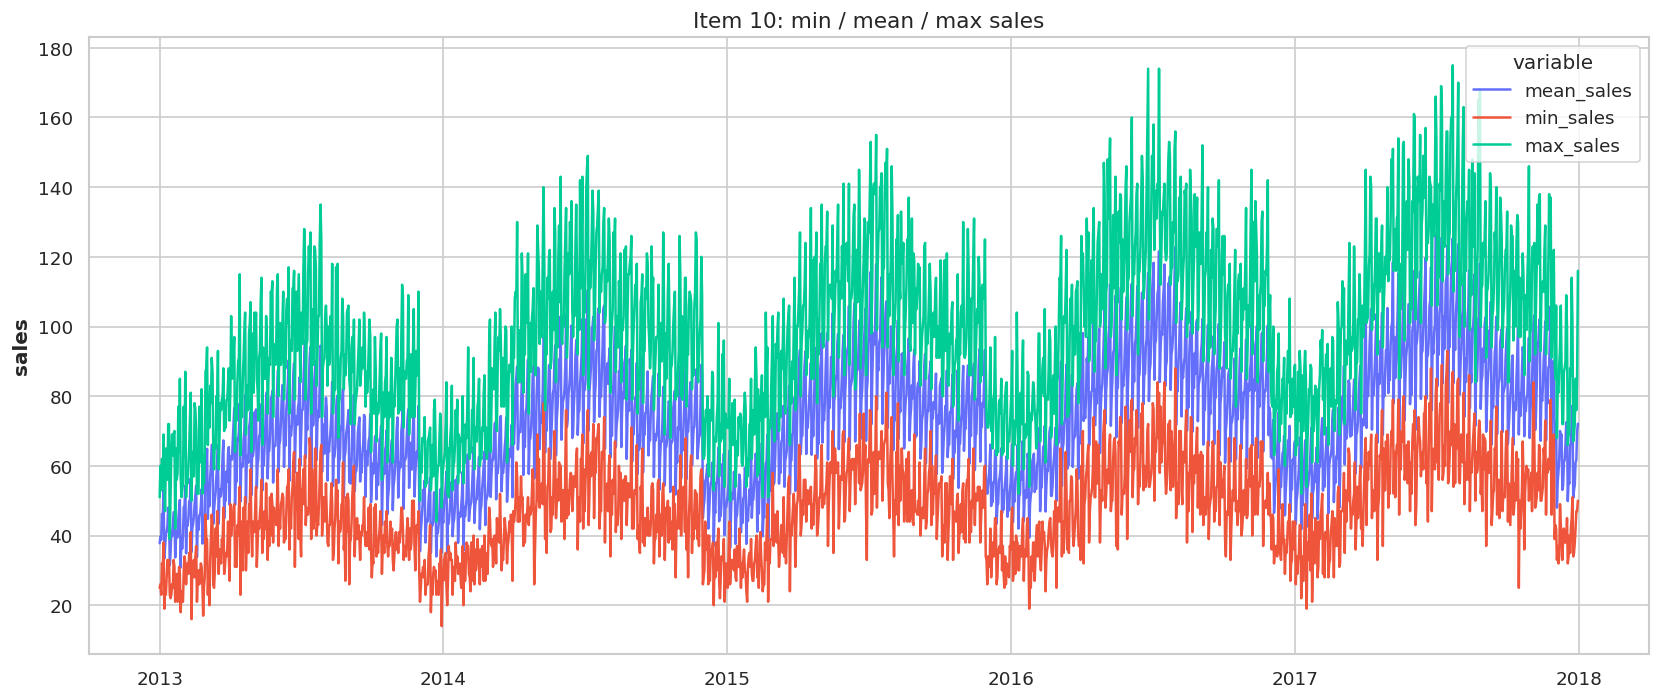

In [46]:
item_id = 10

df_copy = group_df[group_df['item'] == item_id].copy()
df_copy['date'] = pd.to_datetime(df_copy['date'])

plot_df = df_copy.melt(
    id_vars='date',
    value_vars=['mean_sales', 'min_sales', 'max_sales'],
    var_name='variable',
    value_name='value'
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

palette = {
    'mean_sales': '#636EFA',
    'min_sales': '#EF553B',
    'max_sales': '#00CC96'
}

sns.lineplot(
    data=plot_df,
    x='date', y='value',
    hue='variable',
    palette=palette,
    linewidth=1.5,
    ax=ax
)

ax.set_title(f'Item {item_id}: min / mean / max sales', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('sales')

ax.legend(title='variable', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


**Висновок**

З графіка помітно що є невелий зростаючий тренд в продажах. Також є сезонність в межах років і тижнів, яка помітна при масштабуванні.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [47]:
filtered_df = df[(df['item']==1) & (df['store']==1)]

In [48]:
filtered_df

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
...,...,...,...
2017-12-27,1,1,14
2017-12-28,1,1,19
2017-12-29,1,1,15


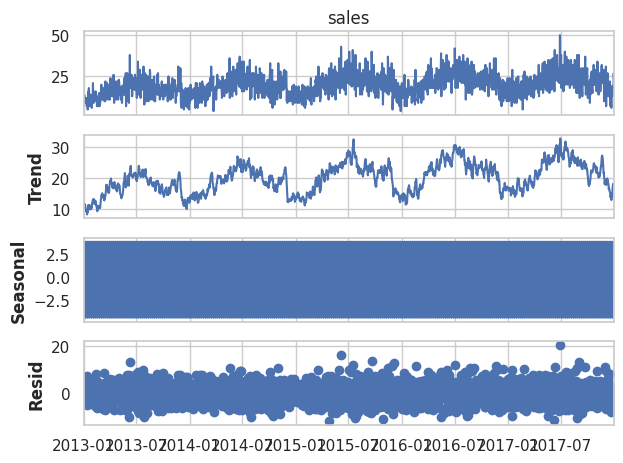

In [49]:
decomposition_plot_multi = seasonal_decompose(filtered_df['sales'],
                                              model='additive')
decomposition_plot_multi.plot()
plt.show()

Можливо допомогло б групування даних по тижнях чи місяцях, але тоді втратиться інформація сезонності в межах тижня

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [50]:
series = TimeSeries.from_dataframe(filtered_df, value_cols='sales')

In [51]:
series

<TimeSeries (date: 1826, component: 1, sample: 1)> Size: 15kB
array([[[13.]],

       [[11.]],

       [[14.]],

       ...,

       [[15.]],

       [[27.]],

       [[23.]]])
Coordinates:
  * date       (date) datetime64[ns] 15kB 2013-01-01 2013-01-02 ... 2017-12-31
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

<Axes: xlabel='date'>

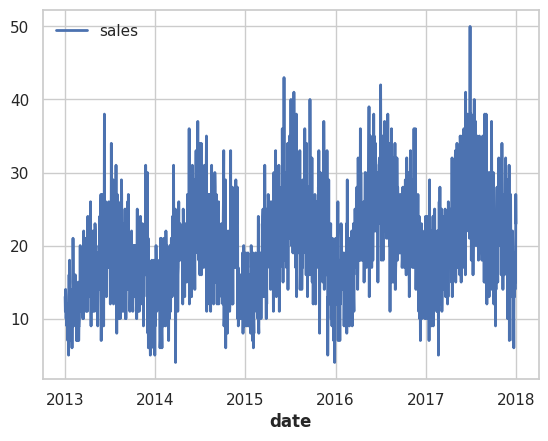

In [52]:
series.plot()

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

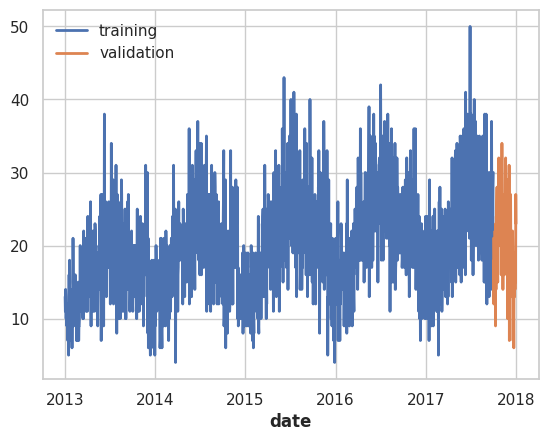

In [53]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x600 with 0 Axes>

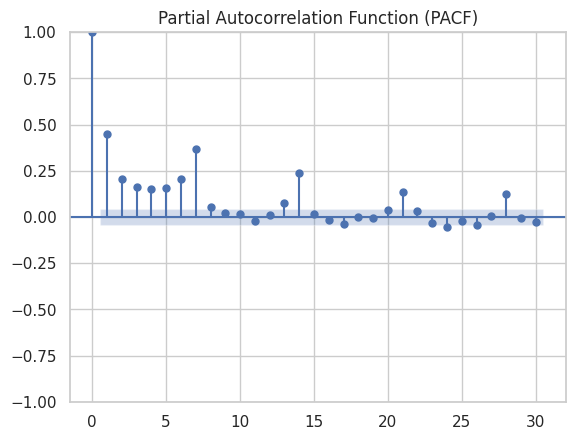

In [54]:
plt.figure(figsize=(10, 6))
plot_pacf(filtered_df['sales'], lags=30, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

Лаги 1-7 мають високу позитивну кореляцію, але особливо виділяється кожен лаг кратний 7 (7, 14, 21, 28, 35, 42, 49). Тобто явно видно сезонність в межах тижня

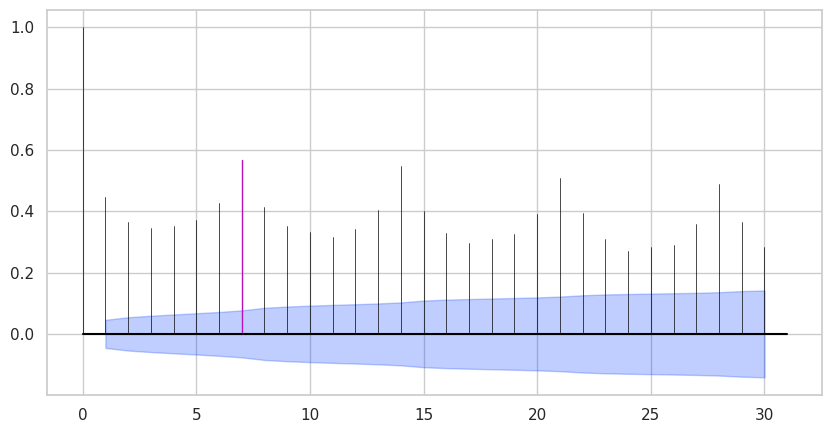

In [55]:
plot_acf(series, m=7, alpha=0.05, max_lag=30)

Тут також видно, що найбільше виділяється кожен 7 лаг.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [56]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [57]:
naive_seasonal_model = NaiveSeasonal(K=7)
naive_seasonal_model.fit(train)
naive_seasonal_forecast = naive_seasonal_model.predict(len(val))

naive_drift_model = NaiveDrift()
naive_drift_model.fit(train)
naive_drift_forecast = naive_drift_model.predict(len(val))

<Axes: xlabel='date'>

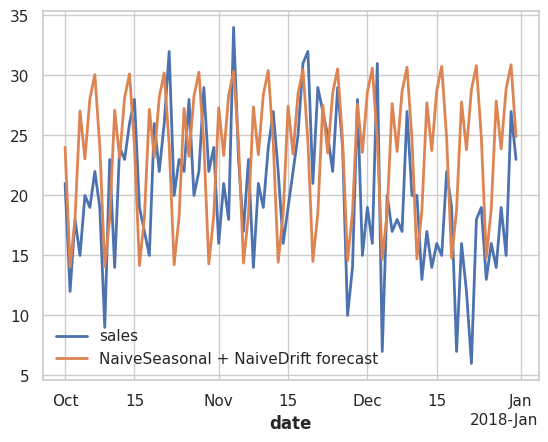

In [58]:
combined_forecast = naive_drift_forecast + naive_seasonal_forecast - train.last_value()

series[-len(val):].plot()
combined_forecast[-len(val):].plot(label="NaiveSeasonal + NaiveDrift forecast")

Якість моделі як на мене задовільна, вона вловила сезонність в межах тижня, але не може врахувати зміни, які не вписуються в цю сезонність

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [59]:
print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 39.91%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [60]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

In [61]:
def enrich_with_date_features(df):
  # Feature Extraction
  # df["hour"] = df['Month'].dt.hour
  df["dayofweek"] = df['date'].dt.dayofweek
  df["quarter"] = df['date'].dt.quarter
  df["month"] = df['date'].dt.month
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  df["dayofmonth"] = df['date'].dt.day
  return df

# Додавання ознак дати
train_transformed = enrich_with_date_features(train.to_dataframe().reset_index())
val_transformed = enrich_with_date_features(val.to_dataframe().reset_index())

# Масштабування даних
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
test_transformed = scaler.transform(val)

# Побудова моделі XGBoost
model = XGBModel(
    lags=500,
    output_chunk_length=1,  # Прогнозування на 1 крок вперед
    n_estimators=100,  # Кількість дерев у моделі
    max_depth=3,  # Максимальна глибина кожного дерева
    learning_rate=0.1,  # Коефіцієнт навчання
    subsample=0.8,  # Частка даних для випадкової вибірки кожного дерева
    colsample_bytree=0.8  # Частка ознак, що використовуються для кожного дерева
)

# Тренування моделі
model.fit(train_transformed)

XGBModel(lags=500, lags_past_covariates=None, lags_future_covariates=None, output_chunk_length=1, output_chunk_shift=0, add_encoders=None, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True, n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)

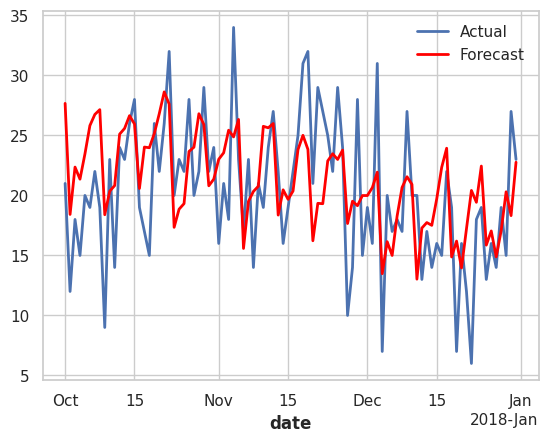

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 26.20%


In [62]:
forecast = scaler.inverse_transform(model.predict(len(val)))
series[-len(val):].plot(label='Actual')
forecast[-len(val):].plot(label='Forecast', color='red')
plt.legend()
plt.show()
eval_forecast(model, val, forecast);

Ця модель показала кращий результат, що видно і візуально, і по значенні метрики MAPE

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [63]:
exp_smooth_model = ExponentialSmoothing()
exp_smooth_model.fit(train)
exp_smooth_forecast = exp_smooth_model.predict(len(val))

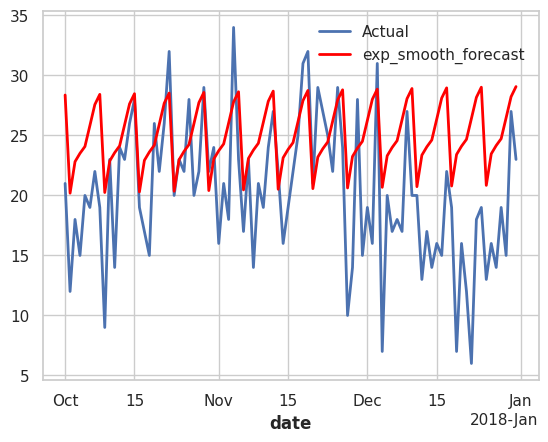

model ExponentialSmoothing() obtains MAPE: 39.01%


In [64]:
series[-len(val):].plot(label='Actual')
exp_smooth_forecast[-len(val):].plot(label='exp_smooth_forecast', color='red')
plt.legend()
plt.show()
eval_forecast(exp_smooth_model, val, exp_smooth_forecast);

Модель показує поганий результат, вона видає просто повторюваний тижневий патерн

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [65]:
arima_model = ARIMA(p=7, d=1, q=5)
arima_model.fit(train)
arima_model_forecast = arima_model.predict(len(val))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


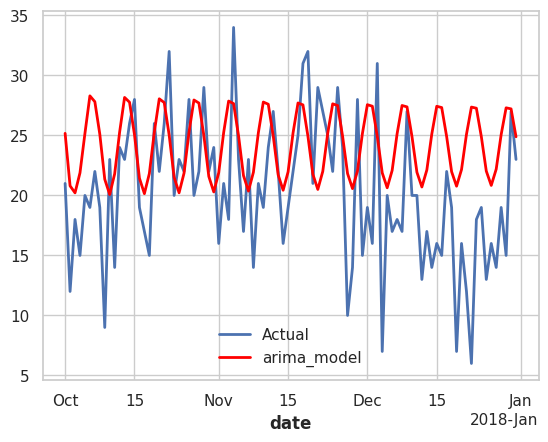

model ARIMA(p=7, q=5) obtains MAPE: 38.05%


In [66]:
series[-len(val):].plot(label='Actual')
arima_model_forecast[-len(val):].plot(label='arima_model', color='red')
plt.legend()
plt.show()
eval_forecast(arima_model, val, arima_model_forecast);

Ця модель вийшла схожою на попередню, також погана

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [67]:
AutoARIMA_model = AutoARIMA(start_p=8, max_p=12, start_q=1)
AutoARIMA_model.fit(train)
display(AutoARIMA_model)

AutoARIMA_model_forecast = AutoARIMA_model.predict(len(val))

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=8, max_p=12, start_q=1)

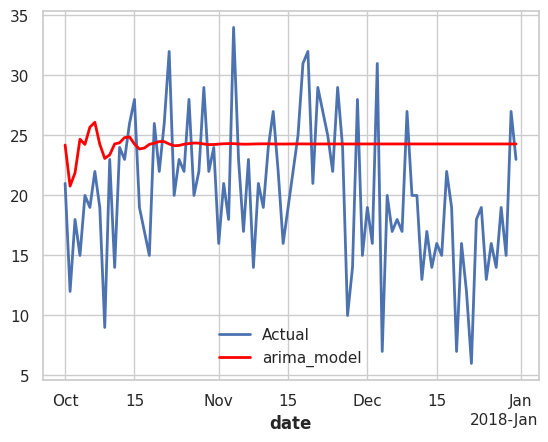

model AutoARIMA(start_p=8, max_p=12, start_q=1) obtains MAPE: 39.49%


In [68]:
series[-len(val):].plot(label='Actual')
AutoARIMA_model_forecast[-len(val):].plot(label='arima_model', color='red')
plt.legend()
plt.show()
eval_forecast(AutoARIMA_model, val, AutoARIMA_model_forecast);

In [69]:
AutoARIMA_model.model.summary()

AttributeError: 'AutoARIMA' object has no attribute 'summary'

На жаль, через брак часу, не вийшло реалізувати так як це було в лекційному ноутбуці, так як схоже зараз відсутній атрибут summary. Пробував різні рішення, наприклад імпорт з pmdarima, що не вийшло через якісь несумісності пакетів як я зрозумів. Також пробував через ARIMA.gridsearch, але результат був поганий

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [70]:
prophet_model = Prophet()
prophet_model.fit(train)
prophet_model_forecast = prophet_model.predict(len(val))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4mp6x56/vyr5msil.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4mp6x56/izjycu1g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47752', 'data', 'file=/tmp/tmpt4mp6x56/vyr5msil.json', 'init=/tmp/tmpt4mp6x56/izjycu1g.json', 'output', 'file=/tmp/tmpt4mp6x56/prophet_model3xu1a8mn/prophet_model-20250831162723.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:27:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:27:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


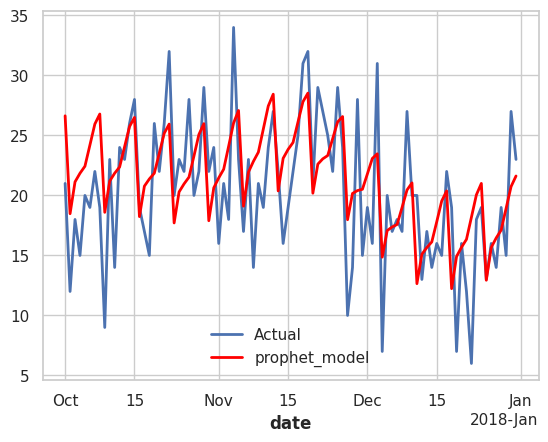

model Prophet() obtains MAPE: 23.80%


In [71]:
series[-len(val):].plot(label='Actual')
prophet_model_forecast[-len(val):].plot(label='prophet_model', color='red')
plt.legend()
plt.show()
eval_forecast(prophet_model, val, prophet_model_forecast);

Модель вийшла краща за попередні, вона вловлює сезонність та краще слідує за трендом, але згладжує максимальні та мінімальні значення порівняно з фактичними даними

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [72]:
rnn_model = RNNModel(model='LSTM', input_chunk_length=7, n_epochs=50)
rnn_model.fit(train)
rnn_model_forecast = rnn_model.predict(len(val))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

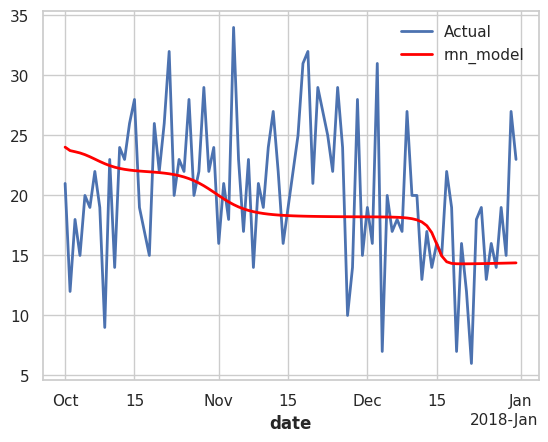

model RNNModel(model=LSTM, input_chunk_length=7, n_epochs=50) obtains MAPE: 26.11%


In [73]:
series[-len(val):].plot(label='Actual')
rnn_model_forecast[-len(val):].plot(label='rnn_model', color='red')
plt.legend()
plt.show()
eval_forecast(rnn_model, val, rnn_model_forecast);

Така модель показала найгірший результат, швидше за все тут треба додатково попрацювати з даними та збильшити кількість епох навчання

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [74]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-01-01"),
    "forecast_horizon": 30,
    "verbose": True,
}

historical_fcast = prophet_model.historical_forecasts(last_points_only=True, **hfc_params)

historical forecasts:   0%|          | 0/336 [00:00<?, ?it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4mp6x56/bqyehlvv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4mp6x56/px9vz5ij.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29639', 'data', 'file=/tmp/tmpt4mp6x56/bqyehlvv.json', 'init=/tmp/tmpt4mp6x56/px9vz5ij.json', 'output', 'file=/tmp/tmpt4mp6x56/prophet_modelrzw3zn56/prophet_model-20250831162943.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:29:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:29:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
historical forecasts:   0%|          | 1/336 [00:00<01:44,  3.21it/s]INFO:prophet

MAPE = 20.37%


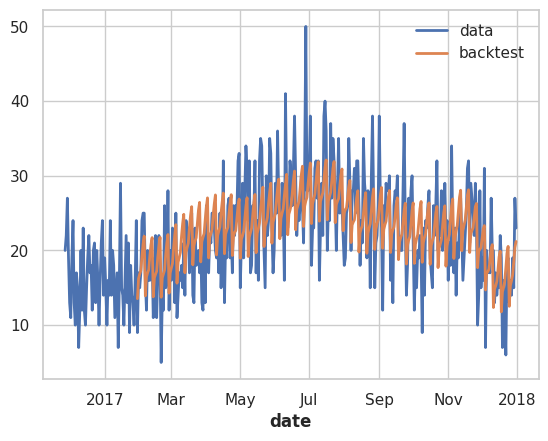

In [77]:
series[-400:].plot(label="data")
historical_fcast[-400:].plot(label="backtest")
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Для такого прогнозування оптимально напевно використовувати глобальну модель, яка навчається на всіх часових рядах одночасно, з урахуванням ідентифікаторів товарів, магазинів. Так як тренувати 500 моделей буде дуже ресурсозатратно і важко підтримувати.

Так як я прочитав, що такі моделі як ExponentialSmoothing, ARIMA, Prophet працюють з одним часовим рядок, то треба використовувати XGBModel чи RNNModel